# Data Loading

In [1]:
import pandas as pd
dataset = pd.read_csv(r'Titanic_Survival.csv')

In [2]:
dataset

,sex,age,fare,Pclass,survived
0,male,22.0,7.2500,3,0
1,female,38.0,71.2833,1,1
2,female,26.0,7.9250,3,1
3,female,35.0,53.1000,1,1
4,male,35.0,8.0500,3,0
...,...,...,...,...,...
886,male,27.0,13.0000,2,0
887,female,19.0,30.0000,1,1
888,female,NaN,23.4500,3,0
889,male,26.0,30.0000,1,1


In [3]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   sex       891 non-null    str    
 1   age       714 non-null    float64
 2   fare      891 non-null    float64
 3   Pclass    891 non-null    int64  
 4   survived  891 non-null    int64  
dtypes: float64(2), int64(2), str(1)
memory usage: 34.9 KB


In [5]:
dataset.shape

(891, 5)

In [6]:
dataset.describe()

,age,fare,Pclass,survived
count,714.000000,891.000000,891.000000,891.000000
mean,29.699118,32.204208,2.308642,0.383838
std,14.526497,49.693429,0.836071,0.486592
min,0.420000,0.000000,1.000000,0.000000
25%,20.125000,7.910400,2.000000,0.000000
50%,28.000000,14.454200,3.000000,0.000000
75%,38.000000,31.000000,3.000000,1.000000
max,80.000000,512.329200,3.000000,1.000000


In [4]:
dataset.isnull().sum()

sex           0
age         177
fare          0
Pclass        0
survived      0
dtype: int64

# Handling Missing Values

In [7]:
mean_age = dataset.age.mean()

dataset.age = dataset.age.fillna(mean_age)

In [9]:
dataset.isnull().sum()

sex         0
age         0
fare        0
Pclass      0
survived    0
dtype: int64

In [10]:
dataset.head()

,sex,age,fare,Pclass,survived
0,male,22.0,7.2500,3,0
1,female,38.0,71.2833,1,1
2,female,26.0,7.9250,3,1
3,female,35.0,53.1000,1,1
4,male,35.0,8.0500,3,0


# Feature Encoding

In [11]:
from sklearn.preprocessing import LabelEncoder

dataset['sex'] = LabelEncoder().fit_transform(dataset['sex'])

dataset     # male: 1    female: 0

x = dataset[['sex','age','fare','Pclass']]

y = dataset['survived']

In [12]:
dataset.head()

,sex,age,fare,Pclass,survived
0,1,22.0,7.2500,3,0
1,0,38.0,71.2833,1,1
2,0,26.0,7.9250,3,1
3,0,35.0,53.1000,1,1
4,1,35.0,8.0500,3,0


# Data Visualization

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

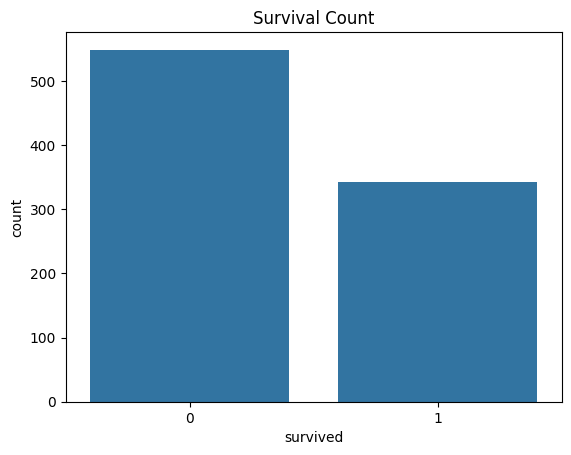

In [20]:
sns.countplot(x='survived', data=dataset)
plt.title("Survival Count")
plt.show()

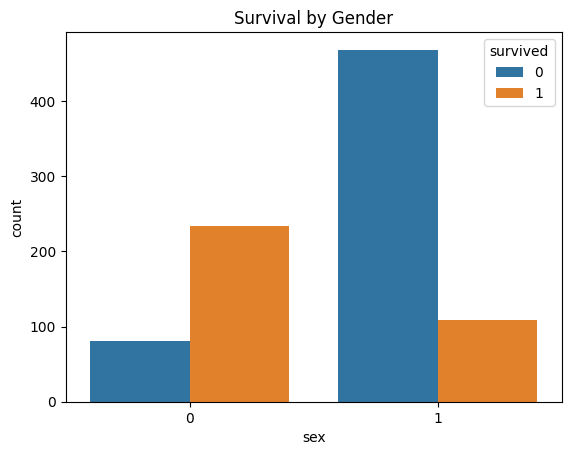

In [21]:
sns.countplot(x='sex', hue='survived', data=dataset)
plt.title("Survival by Gender")
plt.show()

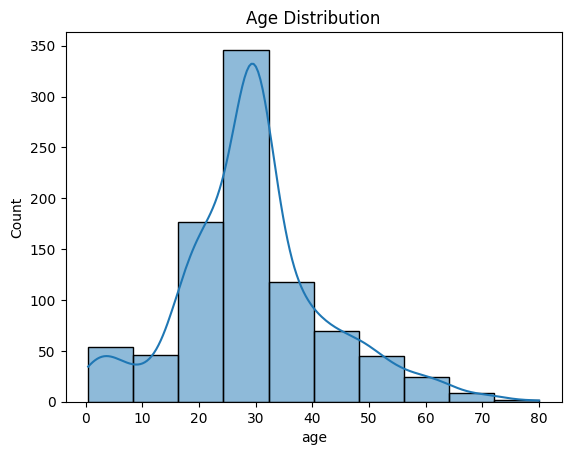

In [23]:
sns.histplot(dataset['age'], bins=10, kde=True)
plt.title("Age Distribution")
plt.show()

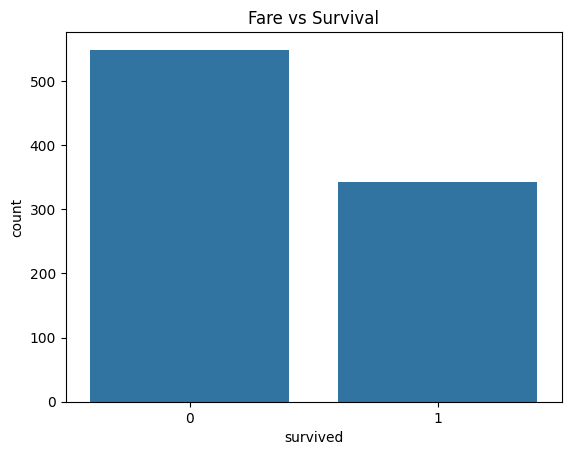

In [27]:
sns.countplot(x='survived', data=dataset)
plt.title("Fare vs Survival")
plt.show()

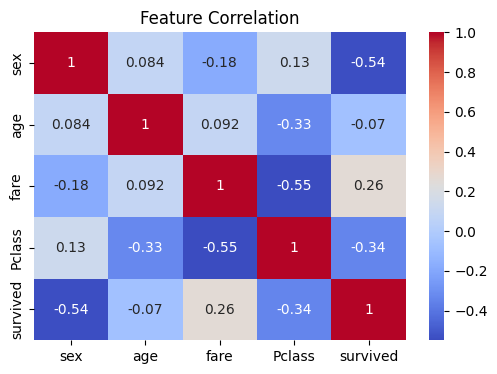

In [28]:
plt.figure(figsize=(6,4))
sns.heatmap(dataset.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

# Train Test Split

In [29]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)

# Decision Tree Classifier

In [39]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import cross_val_score

In [ ]:
from sklearn.tree import DecisionTreeClassifier

classifier = DecisionTreeClassifier(criterion='gini')

classifier.fit(x_train,y_train)

Tree Representation

In [ ]:
from sklearn import tree

tree.plot_tree(classifier)


In [ ]:
y_train_pred = classifier.predict(x_train)
y_test_pred = classifier.predict(x_test)

# probability for ROC-AUC
y_test_proba = classifier.predict_proba(x_test)[:,1]

In [40]:
print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))

print("Precision:", precision_score(y_test, y_test_pred))
print("Recall:", recall_score(y_test, y_test_pred))
print("F1 Score:", f1_score(y_test, y_test_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_test_proba))

Train Accuracy: 0.9803370786516854
Test Accuracy: 0.7877094972067039
Precision: 0.7215189873417721
Recall: 0.7808219178082192
F1 Score: 0.75
ROC-AUC: 0.8000129232359783


In [41]:
cv_acc = cross_val_score(classifier, x_train, y_train, cv=5, scoring='accuracy')
cv_auc = cross_val_score(classifier, x_train, y_train, cv=5, scoring='roc_auc')

print("CV Accuracy (mean):", cv_acc.mean())
print("CV ROC-AUC (mean):", cv_auc.mean())

CV Accuracy (mean): 0.7640500344725697
CV ROC-AUC (mean): 0.7435992851988187


Classification Report

In [42]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.84      0.79      0.82       106
           1       0.72      0.78      0.75        73

    accuracy                           0.79       179
   macro avg       0.78      0.79      0.78       179
weighted avg       0.79      0.79      0.79       179



Confusion Matrix

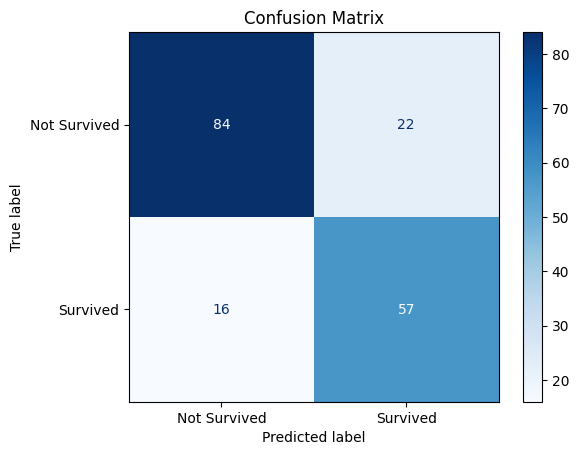

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Survived','Survived'])

disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

ROC Curve (Model Performance)

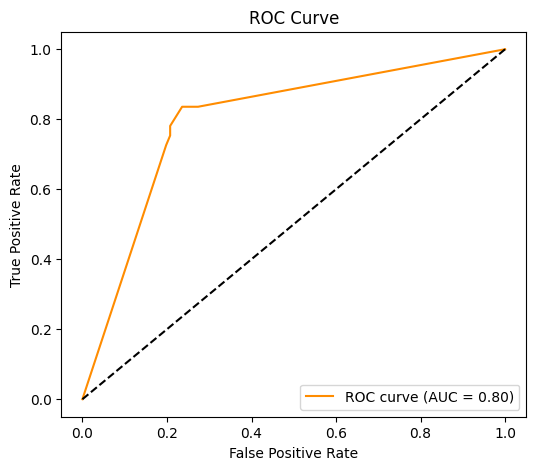

In [44]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

# Feature Importance

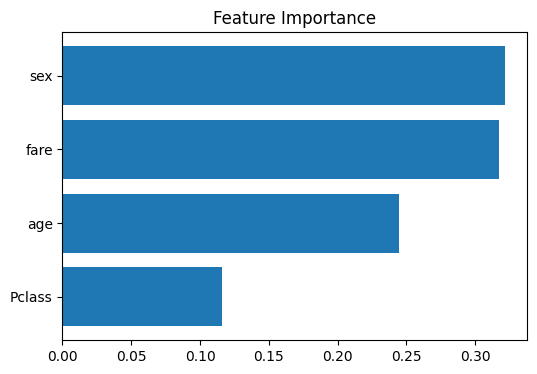

In [ ]:
import pandas as pd

importance = classifier.feature_importances_

features = x_train.columns

importance_df = pd.DataFrame({'Feature': features, 'Importance': importance})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(6,4))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.title("Feature Importance")
plt.gca().invert_yaxis()
plt.show()

# Prediction (For Testing)

In [36]:
sample = pd.DataFrame([[1,9,20.525,3]], columns=['sex','age','fare','Pclass'])
classifier.predict(sample)

array([1])